# Linear Variational Method - Quantum Harmonic Oscillator (QHO)

In this notebook, We will solve using numeric (and symbolic) calculations the Quantum Harmonic Oscillator. We will approximate the energy eigenstates and wavefunctions by using a trial wave function (the variational trial function) that is a linear combination of a basis (specifically, we will use the eigenfunctions of the infinite square well of length L that is symmetric about the origin [-L/2, L/2]). This basis will not be complete since we will cut it and not use the infinite set that will make it complete (because the computer has finite resources).

---

## Table of Contents
* [1. The Hamiltonian](#1-the-hamiltonian)
* [2. The Basis Set (Infinite Square Well)](#2-the-basis-set-infinite-square-well)
* [3. Proof of the Variational Theorem](#3-proof-of-the-variational-theorem)
* [4. Derivation of the Linear Variational Method (The Secular Equation)](#4-derivation-of-the-linear-variational-method-the-secular-equation)
* [5. Analytical Solution of the Infinite Square Well](#5-analytical-solution-of-the-infinite-square-well)
* [6. Analytical Solutions of the Quantum Harmonic Oscillator](#6-analytical-solutions-of-the-quantum-harmonic-oscillator)
* [7. Accelerating the Engine: Analytical Matrix Elements](#7-accelerating-the-engine-analytical-matrix-elements)

---

## 1. The Hamiltonian

The Quantum Harmonic Oscillator is defined by its kinetic and potential energy operators:

$$\hat{H} = \hat{T} + \hat{V} = -\frac{\hbar^2}{2m}\frac{d^2}{dx^2} + \frac{1}{2}m\omega^2 x^2$$

Where $m$ is the mass, $\omega$ is the angular frequency, and $\hbar$ is the reduced Planck's constant. For computational simplicity, we will operate in natural units where $\hbar = m = \omega = 1$.

---

## 2. The Basis Set (Infinite Square Well)

To represent the continuous Hamiltonian operator $\hat{H}$ as a matrix, we must choose a complete set of orthonormal basis functions. We will use the analytical solutions of the 1D Infinite Square Well.

Because our QHO potential is centered at $x=0$, we define our infinite well over a symmetric domain from $-L/2$ to $L/2$. The corresponding normalized basis functions for $n = 1, 2, 3, \dots$ are ([see derivation here](#5-analytical-solution-of-the-infinite-square-well)):


$$\chi_n(x) = \sqrt{\frac{2}{L}} \sin\left(\frac{n\pi(x + L/2)}{L}\right)$$

We will artificially truncate this infinite basis to a finite size $N_{basis}$ to perform our numerical calculations.

---

## 3. Proof of the Variational Theorem

The Variational Principle states that the expectation value of the Hamiltonian for any valid trial wavefunction will always be greater than or equal to the true ground state energy $E_0$. 

### 3.1 Proof using resolution of the identity
**Proof:**
We begin by writing the expression for the expected energy of our trial state:

$$E = \frac{\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle}{\langle \psi_{trial} | \psi_{trial} \rangle}$$

Let $\{|\phi_n\rangle\}$ be the exact, orthonormal eigenstates of the Hamiltonian with exact eigenvalues $E_n$, such that $E_0 \le E_1 \le E_2 \le \dots$

Because these true eigenstates form a complete basis, we can utilize the resolution of the identity (completeness relation):

$$\hat{I} = \sum_{n=0}^{\infty} |\phi_n\rangle\langle\phi_n|$$

We leave the denominator as is, and insert this identity operator between the Hamiltonian and the trial wavefunction in the numerator:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle = \sum_{n=0}^{\infty} \langle \psi_{trial} | \hat{H} | \phi_n \rangle \langle \phi_n | \psi_{trial} \rangle$$

By applying the Hamiltonian operator to its true eigenstate ($\hat{H} | \phi_n \rangle = E_n | \phi_n \rangle$), the expression becomes:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle = \sum_{n=0}^{\infty} E_n \langle \psi_{trial} | \phi_n \rangle \langle \phi_n | \psi_{trial} \rangle$$

Since $E_n \ge E_0$ for all states $n$, we can substitute $E_n$ with the ground state energy $E_0$ to establish an inequality:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle \ge \sum_{n=0}^{\infty} E_0 \langle \psi_{trial} | \phi_n \rangle \langle \phi_n | \psi_{trial} \rangle$$

Because $E_0$ is a constant, it factors out of the summation:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle \ge E_0 \sum_{n=0}^{\infty} \langle \psi_{trial} | \phi_n \rangle \langle \phi_n | \psi_{trial} \rangle$$

We can now recognize the resolution of the identity sitting inside the sum, and use it in reverse to collapse the sum back into the inner product of the trial state:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle \ge E_0 \langle \psi_{trial} | \psi_{trial} \rangle$$

Finally, we substitute this inequality back into our original energy equation:

$$E \ge \frac{E_0 \langle \psi_{trial} | \psi_{trial} \rangle}{\langle \psi_{trial} | \psi_{trial} \rangle}$$

The inner products in the numerator and denominator perfectly cancel, leaving the final proven inequality:

$$E \ge E_0$$

---

### 3.2 Alternative Proof: expansion using eigenstates
**Proof:**
We can also prove the Variational Theorem by explicitly expanding the trial wavefunction as a linear combination of the exact eigenstates. 

Let $\{|\phi_n\rangle\}$ be the exact, orthonormal eigenstates of the Hamiltonian with corresponding exact eigenvalues $E_n$, where $E_0 \le E_1 \le E_2 \le \dots$

We express our arbitrary trial wavefunction $|\psi_{trial}\rangle$ as a linear sum of these true states:

$$|\psi_{trial}\rangle = \sum_{n=0}^{\infty} c_n |\phi_n\rangle$$

Where $c_n$ represents the complex expansion coefficients. 

First, we evaluate the numerator of the energy expectation value, $\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle$:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle = \left( \sum_{m=0}^{\infty} c_{m}^{*} \langle \phi_m | \right) \hat{H} \left( \sum_{n=0}^{\infty} c_n | \phi_n \rangle \right)$$

Applying the Hamiltonian to the right-hand states ($\hat{H} | \phi_n \rangle = E_n | \phi_n \rangle$) yields:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle = \sum_{m=0}^{\infty} \sum_{n=0}^{\infty} c_{m}^{*} c_n E_n \langle \phi_m | \phi_n \rangle$$

Because the exact eigenstates are mutually orthonormal ($\langle \phi_m | \phi_n \rangle = \delta_{mn}$), all terms where $m \neq n$ are zero, and the double sum collapses into a single sum:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle = \sum_{n=0}^{\infty} |c_n|^2 E_n$$

Next, we evaluate the denominator, $\langle \psi_{trial} | \psi_{trial} \rangle$, using the same expansion and orthonormality principle:

$$\langle \psi_{trial} | \psi_{trial} \rangle = \sum_{n=0}^{\infty} |c_n|^2$$

Substituting both of these back into our total energy equation gives:

$$E = \frac{\sum_{n=0}^{\infty} |c_n|^2 E_n}{\sum_{n=0}^{\infty} |c_n|^2}$$

Since the true energies are strictly ordered such that $E_n \ge E_0$ for all $n$, replacing $E_n$ with the ground state energy $E_0$ in the numerator establishes a strict inequality:

$$E \ge \frac{\sum_{n=0}^{\infty} |c_n|^2 E_0}{\sum_{n=0}^{\infty} |c_n|^2}$$

Because $E_0$ is a constant, we can pull it entirely outside the summation:

$$E \ge E_0 \frac{\sum_{n=0}^{\infty} |c_n|^2}{\sum_{n=0}^{\infty} |c_n|^2}$$

The summations of the squared coefficients in the numerator and denominator are identical and cancel out perfectly, proving the theorem:

$$E \ge E_0$$

---

## 4. Derivation of the Linear Variational Method (The Secular Equation)

We now apply the Variational Theorem to a specific type of trial function: a linear combination of a finite, chosen basis set. Let $\{|\chi_j\rangle\}$ be a set of $N_{basis}$ basis functions (in our case, the infinite square well states). 

We express our trial wavefunction as:

$$|\psi_{trial}\rangle = \sum_{j=1}^{N_{basis}} c_j |\chi_j\rangle$$

Where $c_j$ are the unknown expansion coefficients. We substitute this expansion into the variational energy expectation value:

$$E = \frac{\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle}{\langle \psi_{trial} | \psi_{trial} \rangle} = \frac{\sum_{i=1}^{N} \sum_{j=1}^{N} c_{i}^{\ast} c_{j} \langle \chi_{i} | \hat{H} | \chi_{j} \rangle}{\sum_{i=1}^{N} \sum_{j=1}^{N} c_{i}^{\ast} c_{j} \langle \chi_{i} | \chi_{j} \rangle}$$

To simplify the notation, we define two matrix elements:
* **The Hamiltonian Matrix:** $H_{ij} = \langle \chi_i | \hat{H} | \chi_j \rangle$
* **The Overlap Matrix:** $S_{ij} = \langle \chi_i | \chi_j \rangle$

Substituting these into the energy equation yields:

$$E = \frac{\sum_{i,j} c_{i}^{\ast} c_{j} H_{ij}}{\sum_{i,j} c_{i}^{\ast} c_{j} S_{ij}}$$

To avoid taking the derivative of a complex fraction using the quotient rule, we rearrange the equation by multiplying the denominator to the left side:

$$E \sum_{i,j} c_{i}^{\ast} c_{j} S_{ij} = \sum_{i,j} c_{i}^{\ast} c_{j} H_{ij}$$

According to the Variational Principle, the optimal trial wavefunction is the one that minimizes the energy $E$. We find this minimum by requiring that the variation of the energy with respect to the coefficients is zero. In complex calculus, it is standard practice to treat $c_k$ and its complex conjugate $c_{k}^{\ast}$ as independent variables. Therefore, we take the partial derivative of both sides with respect to a specific coefficient $c_{k}^{\ast}$:

$$\frac{\partial E}{\partial c_{k}^{\ast}} \sum_{i,j} c_{i}^{\ast} c_{j} S_{ij} + E \sum_{j} c_{j} S_{kj} = \sum_{j} c_{j} H_{kj}$$

To find the minimum energy, we enforce the minimization condition: $\frac{\partial E}{\partial c_{k}^{*}} = 0$. The first term vanishes entirely, leaving:

$$E \sum_{j} c_j S_{kj} = \sum_{j} c_j H_{kj}$$

We can rearrange this by bringing all terms to one side and factoring out the $c_j$ coefficients:

$$\sum_{j} (H_{kj} - E S_{kj}) c_j = 0$$

This must hold true for all $k = 1, 2, \dots, N_{basis}$. This system of linear equations is known as the **Secular Equation**. Written in compact matrix notation, it becomes the generalized eigenvalue problem:

$$\mathbf{H}\mathbf{c} = E\mathbf{S}\mathbf{c}$$

**Application to our QHO Model:**
Because we have chosen the eigenstates of the infinite square well as our basis, our basis functions are mutually orthonormal. This means the overlap matrix simplifies completely to the identity matrix ($S_{ij} = \delta_{ij}$). Our generalized problem reduces to the standard eigenvalue problem, which we will solve using our Python numerical backend:

$$\mathbf{H}\mathbf{c} = E\mathbf{c}$$

------

> **Historical Note: Why is it called the "Secular" Equation?**
> The term "secular" comes from the Latin word *saeculum*, meaning an age, century, or a very long period of time. In the late 1700s, astronomers like Laplace and Lagrange were studying celestial mechanics, specifically trying to calculate the slow, long-term ("secular") perturbations of planetary orbits—changes that happen over thousands of years, as opposed to short-term periodic changes. 
>
> To find these long-term orbital frequencies, they had to solve a mathematical determinant equation that looked exactly like $|\mathbf{H} - E\mathbf{S}| = 0$. When quantum mechanics was developed a century later and physicists encountered the exact same matrix eigenvalue math, they simply kept the historical astronomy name!

---

## 5. Analytical Solution of the Infinite Square Well

To build our finite basis set, we require the exact analytical solutions to the 1D Infinite Square Well. Because our harmonic oscillator is centered at the origin, we define the boundaries of our infinite well symmetrically at $x = -L/2$ and $x = L/2$. 

The potential energy function is defined as:

$$V(x) = \begin{cases} 0 & -L/2 \le x \le L/2 \\ \infty & \text{otherwise} \end{cases}$$

Inside the well where $V(x) = 0$, the Time-Independent Schrödinger Equation simplifies to:

$$-\frac{\hbar^2}{2m}\frac{d^2\chi}{dx^2} = E\chi$$

We can rewrite this as a standard second-order differential equation:

$$\frac{d^2\chi}{dx^2} + k^2\chi = 0 \quad \text{where} \quad k = \frac{\sqrt{2mE}}{\hbar}$$

To make applying the boundary conditions mathematically simpler, we can introduce a coordinate transformation $u = x + L/2$. This shifts the left wall to $u = 0$ and the right wall to $u = L$. The general solution to the differential equation in this shifted coordinate system is:

$$\chi(u) = A \sin(ku) + B \cos(ku)$$

We now apply the impenetrable boundary conditions. The wavefunction must go to zero at the walls:

1.  **Left Wall (**$u = 0$**):**
    $$\chi(0) = A \sin(0) + B \cos(0) = B = 0$$
    This eliminates the cosine term entirely, leaving $\chi(u) = A \sin(ku)$.

2.  **Right Wall (**$u = L$**):**
    $$\chi(L) = A \sin(kL) = 0$$
    For a non-trivial solution ($A \neq 0$), the argument of the sine function must be an integer multiple of $\pi$:
    $$kL = n\pi \implies k_n = \frac{n\pi}{L} \quad \text{for} \quad n = 1, 2, 3, \dots$$

Substituting our momentum wave vector $k_n$ back into the energy definition $k^2 = 2mE/\hbar^2$ yields the exact energy eigenvalues for the infinite well:

$$E_n = \frac{n^2 \pi^2 \hbar^2}{2mL^2}$$

To find the normalization constant $A$, we require the total probability of finding the particle inside the well to be exactly 1:

$$1 = \int_{-L/2}^{L/2} |\chi_n(x)|^2 dx = A^2 \int_{0}^{L} \sin^2\left(\frac{n\pi u}{L}\right) du$$

Evaluating the integral gives $L/2$, which means:

$$A^2 \left(\frac{L}{2}\right) = 1 \implies A = \sqrt{\frac{2}{L}}$$

Finally, we substitute $A$, $k_n$, and our original coordinate $x = u - L/2$ back into the wavefunction to get the complete, normalized basis functions used in our variational matrix:

$$\chi_n(x) = \sqrt{\frac{2}{L}} \sin\left(\frac{n\pi(x + L/2)}{L}\right)$$

---

## 6. Analytical Solutions of the Quantum Harmonic Oscillator

Before visualizing our numerical results, it is instructive to review the exact analytical solutions of the QHO. We can derive these solutions using two distinct methods: solving the differential equation directly, and using the algebraic method of ladder operators.

### 6.1 Method 1: The Differential Equation Approach

We begin with the Time-Independent Schrödinger Equation (TISE) for the 1D harmonic oscillator:

$$-\frac{\hbar^2}{2m}\frac{d^2\psi}{dx^2} + \frac{1}{2}m\omega^2 x^2 \psi = E\psi$$

To simplify the math, we introduce a dimensionless coordinate $\xi = \sqrt{\frac{m\omega}{\hbar}}x$ and a dimensionless energy $\epsilon = \frac{2E}{\hbar\omega}$. The TISE simplifies to:

$$\frac{d^2\psi}{d\xi^2} + (\epsilon - \xi^2)\psi = 0$$

**1. The Asymptotic Envelope:**
We first examine the behavior of the wavefunction at extreme distances ($\xi \to \pm\infty$). In this limit, $\xi^2 \gg \epsilon$, so the equation simplifies to $\frac{d^2\psi}{d\xi^2} \approx \xi^2\psi$. The normalizable solution to this asymptotic equation is a Gaussian function, $\psi(\xi) \sim e^{-\xi^2/2}$. 

**2. The Hermite Differential Equation:**
Knowing the asymptotic behavior, we can factor out this Gaussian envelope and express the full wavefunction as the product of the envelope and some unknown function $h(\xi)$:

$$\psi(\xi) = h(\xi)e^{-\xi^2/2}$$

Substituting this guess back into our exact dimensionless TISE and simplifying yields:

$$\frac{d^2h}{d\xi^2} - 2\xi\frac{dh}{d\xi} + (\epsilon - 1)h = 0$$

This is the well-known **Hermite Differential Equation**. For the solutions to remain finite (and thus normalizable), the term $(\epsilon - 1)$ must be an even integer $2n$, where $n = 0, 1, 2, \dots$. This condition strictly quantizes our energy:

$$\epsilon - 1 = 2n \implies \frac{2E}{\hbar\omega} - 1 = 2n \implies E_n = \hbar\omega\left(n + \frac{1}{2}\right)$$

The solutions for $h(\xi)$ are the physicist's Hermite polynomials, $H_n(\xi)$. 

**3. Normalization:**
The full wavefunction is $\psi_n(\xi) = N_n H_n(\xi) e^{-\xi^2/2}$. To find the normalization constant $N_n$, we require the total probability to be 1:

$$\int_{-\infty}^{\infty} |\psi_n(x)|^2 dx = 1$$

Converting $dx$ to $d\xi$ gives $dx = \sqrt{\frac{\hbar}{m\omega}} d\xi$. Using the standard orthogonality integral for Hermite polynomials ($\int_{-\infty}^{\infty} H_n^2(\xi) e^{-\xi^2} d\xi = \sqrt{\pi} 2^n n!$), we solve for the constant:

$$|N_n|^2 \sqrt{\frac{\hbar}{m\omega}} \sqrt{\pi} 2^n n! = 1 \implies N_n = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4} \frac{1}{\sqrt{2^n n!}}$$

Substituting the physical coordinate $\xi = \sqrt{\frac{m\omega}{\hbar}}x$ and our derived normalization constant $N_n$ back into the general solution $\psi_n(\xi) = N_n H_n(\xi) e^{-\xi^2/2}$ gives the final, explicit wavefunctions entirely in terms of the position $x$:

$$\psi_n(x) = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4} \frac{1}{\sqrt{2^n n!}} \exp\left(-\frac{m\omega}{2\hbar}x^2\right) H_n\left(\sqrt{\frac{m\omega}{\hbar}} x\right)$$

For clarity, substituting the first three Hermite polynomials ($H_0(\xi)=1$, $H_1(\xi)=2\xi$, $H_2(\xi)=4\xi^2-2$) gives the explicit forms for the lowest energy states:

* **Ground State ($n=0$):** $$\psi_0(x) = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4} \exp\left(-\frac{m\omega}{2\hbar}x^2\right)$$

* **First Excited State ($n=1$):** $$\psi_1(x) = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4} \sqrt{\frac{2m\omega}{\hbar}} x \exp\left(-\frac{m\omega}{2\hbar}x^2\right)$$

* **Second Excited State ($n=2$):** $$\psi_2(x) = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4} \frac{1}{\sqrt{2}} \left(2\frac{m\omega}{\hbar}x^2 - 1\right) \exp\left(-\frac{m\omega}{2\hbar}x^2\right)$$

---

### 6.2 Method 2: The Algebraic (Ladder Operator) Approach

A more elegant approach avoids second-order differential equations entirely by factoring the Hamiltonian. We define the annihilation ($\hat{a}$) and creation ($\hat{a}^\dagger$) operators:

$$\hat{a} = \sqrt{\frac{m\omega}{2\hbar}}\left(\hat{x} + \frac{i}{m\omega}\hat{p}\right), \quad \hat{a}^\dagger = \sqrt{\frac{m\omega}{2\hbar}}\left(\hat{x} - \frac{i}{m\omega}\hat{p}\right)$$

Using the fundamental commutation relation $[\hat{x}, \hat{p}] = i\hbar$, we find $[\hat{a}, \hat{a}^\dagger] = 1$. This allows us to rewrite the Hamiltonian entirely in terms of these operators:

$$\hat{H} = \hbar\omega\left(\hat{a}^\dagger\hat{a} + \frac{1}{2}\right)$$

**1. Finding the Ground State:**
The operator $\hat{a}$ lowers the energy of a state by one quanta. Since energy cannot be negative, there must be a lowest ground state $\psi_0$ that is entirely destroyed by the lowering operator: $\hat{a}\psi_0 = 0$. 

Writing $\hat{a}$ in terms of $x$ and the momentum operator $\hat{p} = -i\hbar\frac{d}{dx}$, we get a simple first-order differential equation:

$$\left(\sqrt{\frac{m\omega}{2\hbar}}x + \frac{\hbar}{\sqrt{2m\hbar\omega}}\frac{d}{dx}\right)\psi_0 = 0 \implies \frac{d\psi_0}{dx} = -\frac{m\omega}{\hbar}x \psi_0$$

Integrating this directly yields the exact same Gaussian ground state we found in Method 1:

$$\psi_0(x) = A e^{-\frac{m\omega}{2\hbar}x^2}$$

**2. Building the Excited States:**
With the ground state established, we can generate any excited state simply by repeatedly applying the creation operator. The normalized $n$-th excited state is given by:

$$\psi_n = \frac{1}{\sqrt{n!}}(\hat{a}^\dagger)^n \psi_0$$

> **Computational Note:** In our code, we use natural units ($\hbar = m = \omega = 1$). This simplifies the exact normalized wavefunctions to:
> $$\psi_n(x) = \frac{1}{\sqrt{2^n n! \sqrt{\pi}}} \exp\left(-\frac{x^2}{2}\right) H_n(x)$$

---

## 7. Accelerating the Engine: Analytical Matrix Elements

Calculating the Hamiltonian matrix is the primary computational bottleneck of the Variational Method. For a basis size of $N_{basis} = 50$, the symmetric matrix requires evaluating exactly 1,275 unique potential energy integrals. 

Because the Hamiltonian is a symmetric matrix ($H_{nk} = H_{kn}$), we do not need to calculate all $N^2$ elements. We only need to compute the main diagonal (N) and the super diagonal (N - 1) and the super super diagonal (N - 2) and so on until 1. This is an arithmetic sum! The formula for this (credit to 8 year old Gauss) is:
$$\text{Unique Integrals} = (N) + (N - 1) + (N - 2) + ... + (1) = \frac{N(N+1)}{2}$$

While a numerical integration suite (accessible via the `config.py` file) is vital for simulating arbitrary or anharmonic potentials, relying on numerical quadrature for the QHO means evaluating the function at roughly a million distinct grid points every time the matrix is built. To massively accelerate the engine for this specific problem, we can use the exact, closed-form algebraic solution for the potential energy matrix elements ($V_{nk}$). 

The matrix elements are defined by the inner product of the potential operator with our infinite square well basis states:

$$V_{nk} = \langle \chi_n | \hat{V} | \chi_k \rangle = \int_{-L/2}^{L/2} \chi_n(x) \hat{V}(x) \chi_k(x) dx$$

Substituting the harmonic oscillator potential $\hat{V}(x) = \frac{1}{2}m\omega^2 x^2$ and our basis functions, the exact integral becomes:

$$V_{nk} = \frac{m\omega^2}{L} \int_{-L/2}^{L/2} x^2 \sin\left(\frac{n\pi(x + L/2)}{L}\right) \sin\left(\frac{k\pi(x + L/2)}{L}\right) dx$$

Because these integral bounds are symmetric around zero, integrating the shifted arguments of the sine functions directly is algebraically tedious. To make this integral much easier to evaluate analytically using a symbolic mathematics library like SymPy, we apply a coordinate transformation $u = x + L/2$. 

This shifts the integration bounds to $[0, L]$ and changes the $x^2$ term to $(u - L/2)^2$:

$$V_{nk} = \frac{m\omega^2}{L} \int_{0}^{L} \left(u - \frac{L}{2}\right)^2 \sin\left(\frac{n\pi u}{L}\right) \sin\left(\frac{k\pi u}{L}\right) du$$

This integral consists entirely of polynomials multiplied by trigonometric functions, which means it has an exact analytical solution via recursive integration by parts. Instead of solving it by hand, we use SymPy to evaluate this integral symbolically. We then compile the result into a lightning-fast Python function that is triggered whenever `cfg.integration_method = 'analytical'` is selected, leaving the robust numerical solvers safely intact as another option.

In [19]:
%load_ext autoreload
%autoreload 2

import numpy as np
import math
import matplotlib.pyplot as plt

import config as cfg
from qho_solver import calculate_qho_energies_and_states, reconstruct_numerical_wavefunction, exact_qho_wavefunction

# --- Dashboard Output ---
print("=" * 50)
print(" ⚛️ QUANTUM HARMONIC OSCILLATOR ENGINE INITIALIZED")
print("=" * 50)

print("⚙️  PHYSICAL PARAMETERS:")
print(f"    hbar     = {cfg.HBAR}")
print(f"    Mass (m) = {cfg.MASS}")
print(f"    Omega (ω)= {cfg.OMEGA}")
print("-" * 50)

print("📊 BASELINE DEFAULTS:")
print(f"    Box Size (L)    = {cfg.DEFAULT_L}")
print(f"    Basis Size (N)  = {cfg.DEFAULT_N_BASIS}")
print(f"    States Tracked  = {cfg.DEFAULT_N_STATES}")
print("-" * 50)

print("🛠️  NUMERICAL METHODS:")
print(f"    Integration Engine = '{cfg.integration_method}'")
print(f"    Eigensolver        = '{cfg.eigenvalue_method}'")
print("-" * 50)

print("=" * 50)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
 ⚛️ QUANTUM HARMONIC OSCILLATOR ENGINE INITIALIZED
⚙️  PHYSICAL PARAMETERS:
    hbar     = 1.0
    Mass (m) = 1.0
    Omega (ω)= 1.0
--------------------------------------------------
📊 BASELINE DEFAULTS:
    Box Size (L)    = 25.0
    Basis Size (N)  = 100
    States Tracked  = 38
--------------------------------------------------
🛠️  NUMERICAL METHODS:
    Integration Engine = 'analytical'
    Eigensolver        = 'scipy'
--------------------------------------------------


In [20]:
# Maybe calculate S matrix here for generality, but for the infinite square well, the basis functions are orthonormal, so S = I (identity matrix).

In [21]:
# ==========================================
# Single Run using Defaults
# ==========================================

print(f"Running Sanity Check with L={cfg.DEFAULT_L}, N_BASIS={cfg.DEFAULT_N_BASIS}")

# 1. Run the pipeline
test_energies, test_states = calculate_qho_energies_and_states(
    L_val=cfg.DEFAULT_L, 
    N_BASIS_val=cfg.DEFAULT_N_BASIS, 
    N_STATES_val=cfg.DEFAULT_N_STATES
)

# 2. Calculate the exact theoretical energies (E_n = n + 0.5) # TODO: maybe save this somewhere else to avoid code duplication
exact_energies = np.array([(cfg.HBAR * cfg.OMEGA) * (n + 0.5) for n in range(cfg.DEFAULT_N_STATES)])

# 3. Calculate absolute error
errors = np.abs(test_energies - exact_energies)

# 4. Display Results
print("\nExact Energies:    ", exact_energies)
print("Computed Energies: ", test_energies)
print("Absolute Errors:   ", errors)

Running Sanity Check with L=25.0, N_BASIS=100

Exact Energies:     [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5 27.5
 28.5 29.5 30.5 31.5 32.5 33.5 34.5 35.5 36.5 37.5]
Computed Energies:  [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5 27.5
 28.5 29.5 30.5 31.5 32.5 33.5 34.5 35.5 36.5 37.5]
Absolute Errors:    [3.33066907e-16 1.55431223e-14 1.24344979e-14 1.15463195e-14
 1.06581410e-14 6.21724894e-15 1.33226763e-14 9.76996262e-15
 1.06581410e-14 2.30926389e-14 1.77635684e-14 5.32907052e-15
 1.59872116e-14 1.24344979e-14 1.77635684e-14 8.88178420e-15
 1.77635684e-14 3.55271368e-15 0.00000000e+00 3.55271368e-15
 1.42108547e-14 1.06581410e-14 7.10542736e-15 3.55271368e-15
 1.77635684e-14 1.77635684e-14 1.42108547e-14 7.10542736e-15
 7.10542736e-15 1.42108547e-14 7.10542736e-15 0.00000000e+00
 7.10542736e-15 7

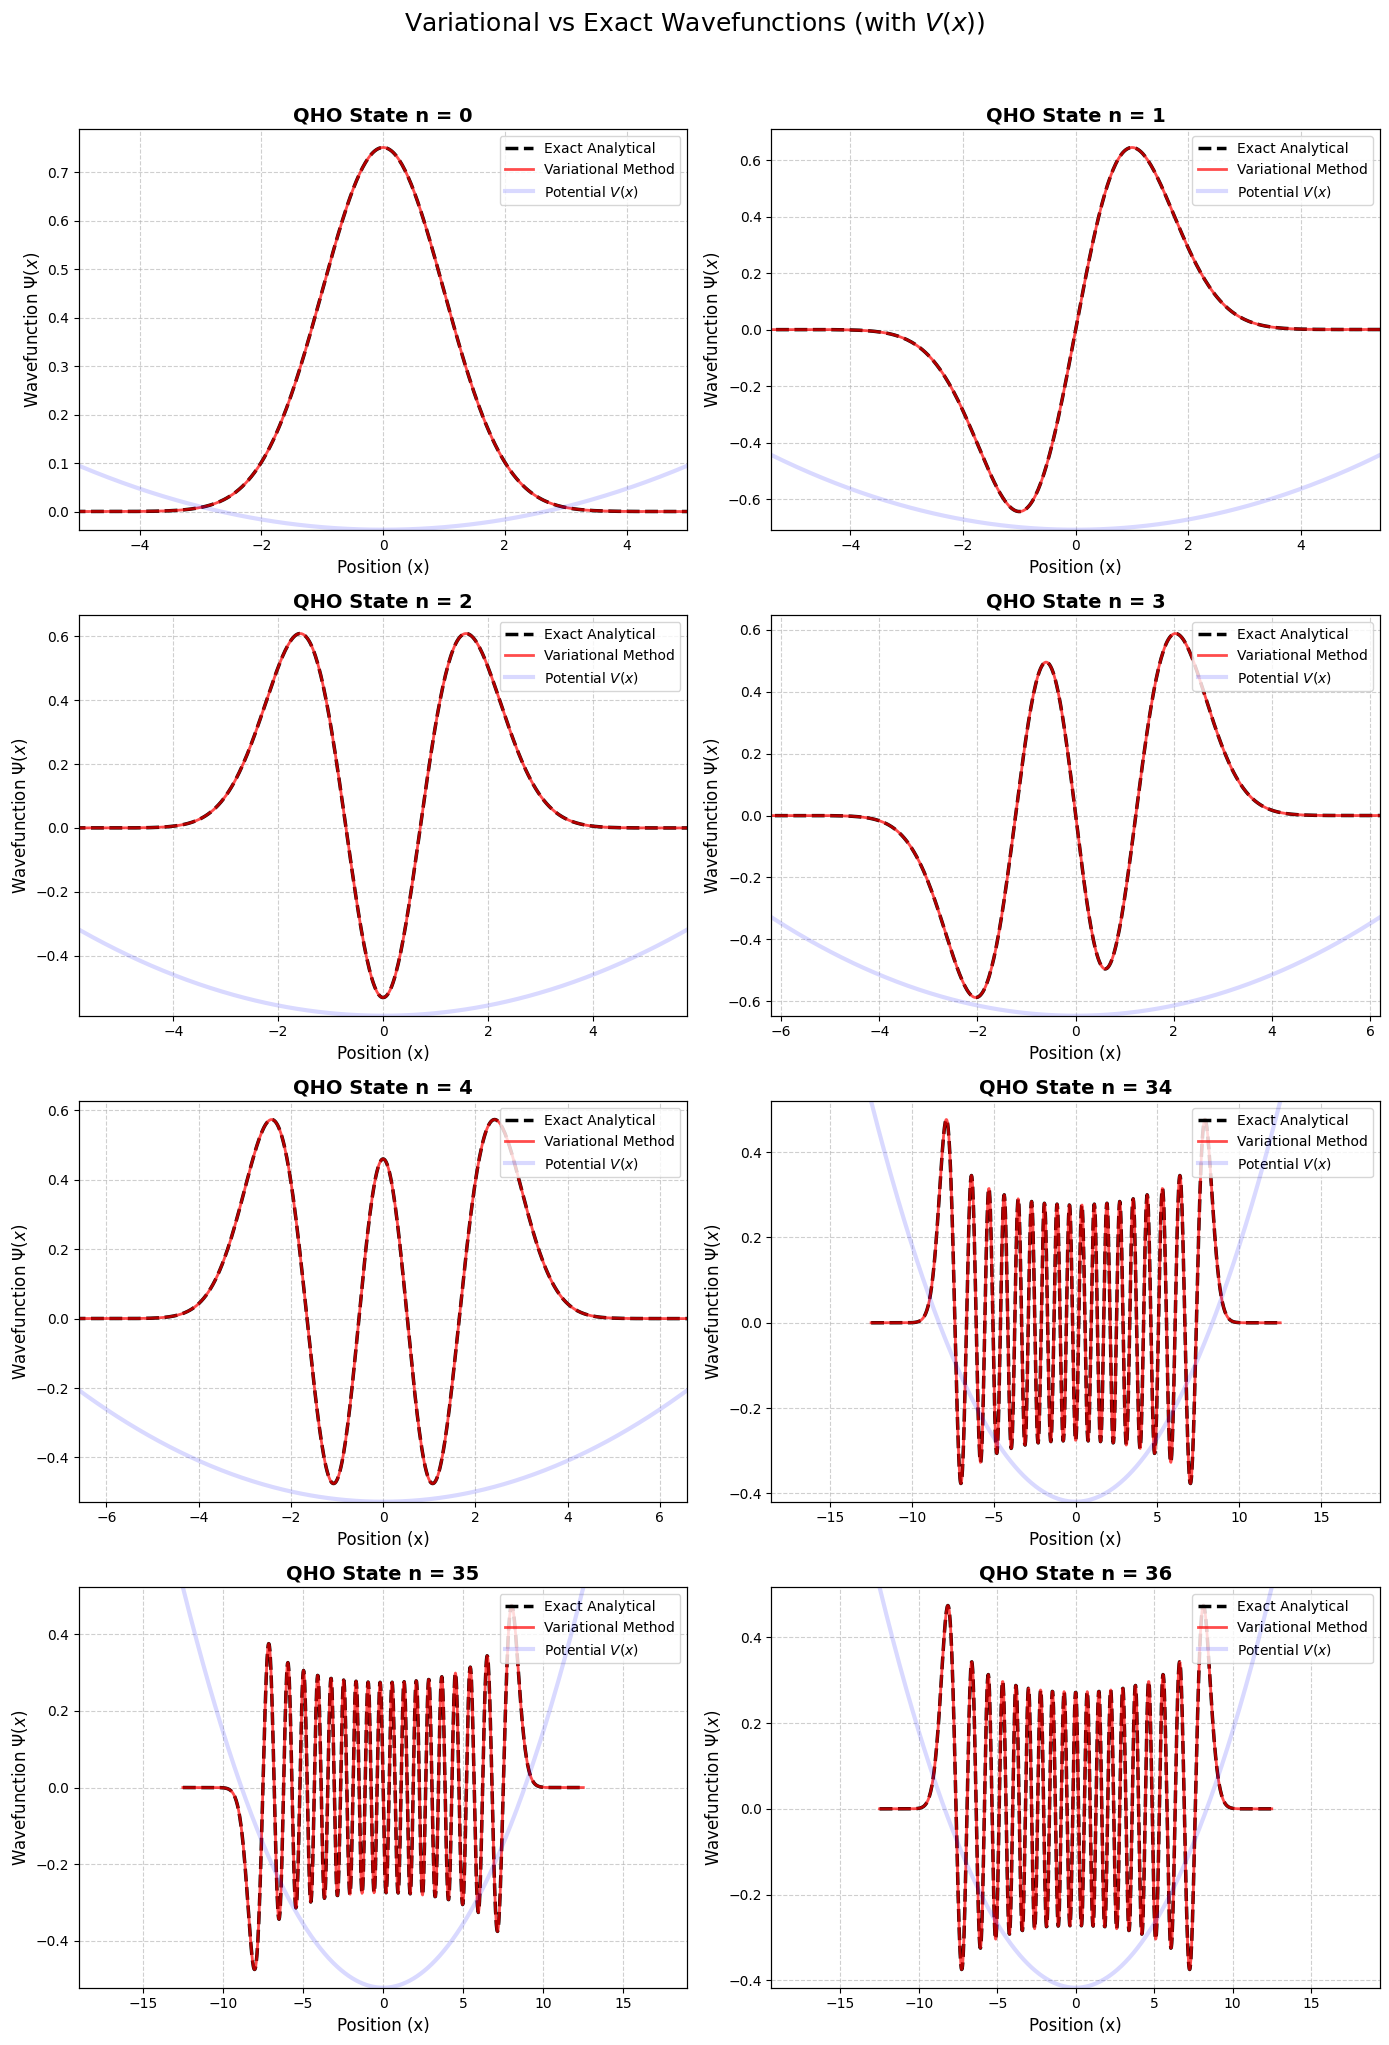

In [22]:
# ==========================================
# Visualizing Multiple States (With Background Potential)
# ==========================================

states_to_plot = [0, 1, 2, 3, 4, cfg.DEFAULT_N_STATES - 4, cfg.DEFAULT_N_STATES - 3, cfg.DEFAULT_N_STATES - 2]

# --- Dynamic Grid Calculation ---
num_states = len(states_to_plot)
cols = 2
rows = math.ceil(num_states / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))

if num_states <= 2:
    axes = np.array(axes).flatten()
else:
    axes = axes.flatten() 

# Create the spatial grid for plotting
x_visual = np.linspace(-cfg.DEFAULT_L/2, cfg.DEFAULT_L/2, 1000)

# Calculate the potential energy curve: V(x) = 0.5 * m * w^2 * x^2
V_x = 0.5 * cfg.MASS * (cfg.OMEGA * x_visual)**2

for idx, ax in enumerate(axes):
    
    if idx >= num_states:
        ax.axis('off')
        continue
        
    state = states_to_plot[idx]
    
    # 1. Wavefunctions
    psi_exact = exact_qho_wavefunction(x_visual, state)
    eigenvector = test_states[:, state]
    psi_num = reconstruct_numerical_wavefunction(x_visual, cfg.DEFAULT_L, cfg.DEFAULT_N_BASIS, eigenvector)
    
    # 2. Phase Matching
    peak_idx = np.argmax(np.abs(psi_exact))
    if np.sign(psi_num[peak_idx]) != np.sign(psi_exact[peak_idx]):
        psi_num *= -1
        
    # 3. Plot the Wavefunctions (Primary Axis)
    ax.plot(x_visual, psi_exact, 'k--', linewidth=2.5, label='Exact Analytical')
    ax.plot(x_visual, psi_num, 'r-', alpha=0.7, linewidth=2, label='Variational Method')
    
    # 4. Plot the Background Potential (Secondary Axis)
    ax_V = ax.twinx() # Create a twin axis sharing the same x-axis
    ax_V.plot(x_visual, V_x, 'b-', alpha=0.15, linewidth=3, label='Potential $V(x)$')
    
    # Lock the bottom of the parabola to the bottom of the graph and hide its numbers
    ax_V.set_ylim([0, max(V_x)])
    ax_V.set_yticks([]) 
    
    # Beautify the subplot
    ax.set_title(f'QHO State n = {state}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Position (x)', fontsize=12)
    ax.set_ylabel(r'Wavefunction $\Psi(x)$', fontsize=12) 
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Combine the legends from both the primary and secondary axes
    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax_V.get_legend_handles_labels()
    ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')
    
    # Dynamically zoom the x-axis
    view_limit = 5 + (state * 0.4) 
    ax.set_xlim([-view_limit, view_limit]) 

plt.suptitle('Variational vs Exact Wavefunctions (with $V(x)$)', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

Sweeping N_BASIS from 20 to 100 with fixed L=30.0...


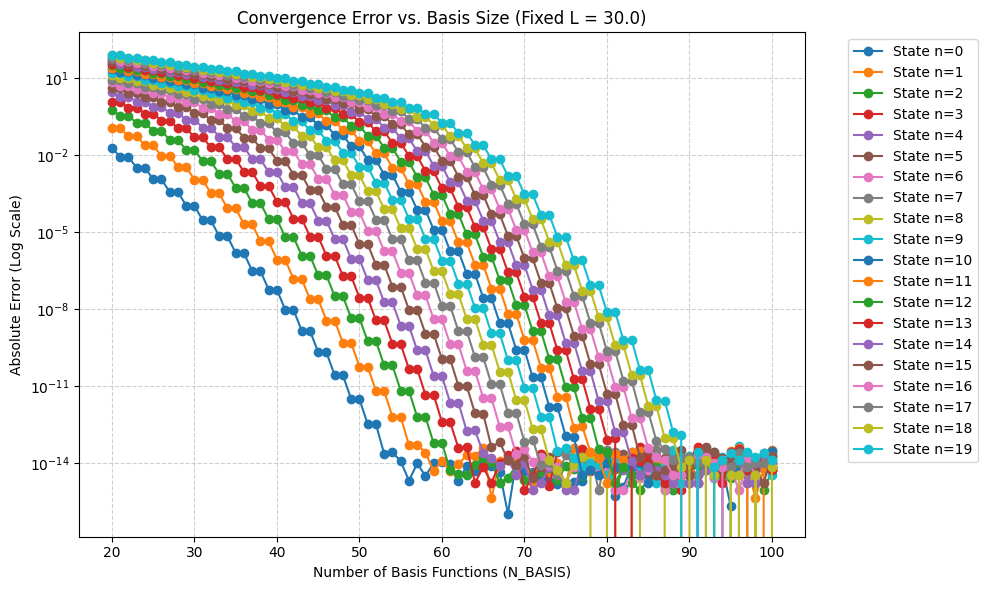

In [23]:
# ==========================================
# Modifying the parameter N_BASIS: Error vs. N_BASIS (Fixed L)
# ==========================================

# Experimental Setup
L_fixed = 30.0 
N_BASIS_min = 20
N_BASIS_max = 100
N_BASIS_step_size = 1

basis_sizes = np.arange(N_BASIS_min, N_BASIS_max + N_BASIS_step_size, N_BASIS_step_size)
tracked_states = 20

# Calculate exact theoretical energies
exact_energies = np.array([(cfg.HBAR * cfg.OMEGA) * (n + 0.5) for n in range(tracked_states)]) 
errors_vs_N = []

print(f"Sweeping N_BASIS from {N_BASIS_min} to {N_BASIS_max} with fixed L={L_fixed}...")

for N in basis_sizes:
    # Cast N to int to ensure NumPy matrix creation doesn't break
    calc_energies, _ = calculate_qho_energies_and_states(
        L_val=L_fixed, 
        N_BASIS_val=int(N), 
        N_STATES_val=tracked_states
    )
    
    # Calculate the absolute error against the theoretical formula
    error = np.abs(calc_energies - exact_energies)
    errors_vs_N.append(error)

# Convert list to a 2D NumPy array for easy plotting slicing
errors_vs_N = np.array(errors_vs_N)

# --- Matplotlib Plotting ---
plt.figure(figsize=(10, 6))
for state in range(tracked_states):
    # Using a logarithmic y-axis to see the exponential convergence
    plt.semilogy(basis_sizes, errors_vs_N[:, state], marker='o', label=f'State n={state}')

plt.title(f'Convergence Error vs. Basis Size (Fixed L = {L_fixed})')
plt.xlabel('Number of Basis Functions (N_BASIS)')
plt.ylabel('Absolute Error (Log Scale)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

Sweeping L from 1.0 to 50.0 with fixed N_BASIS=100...


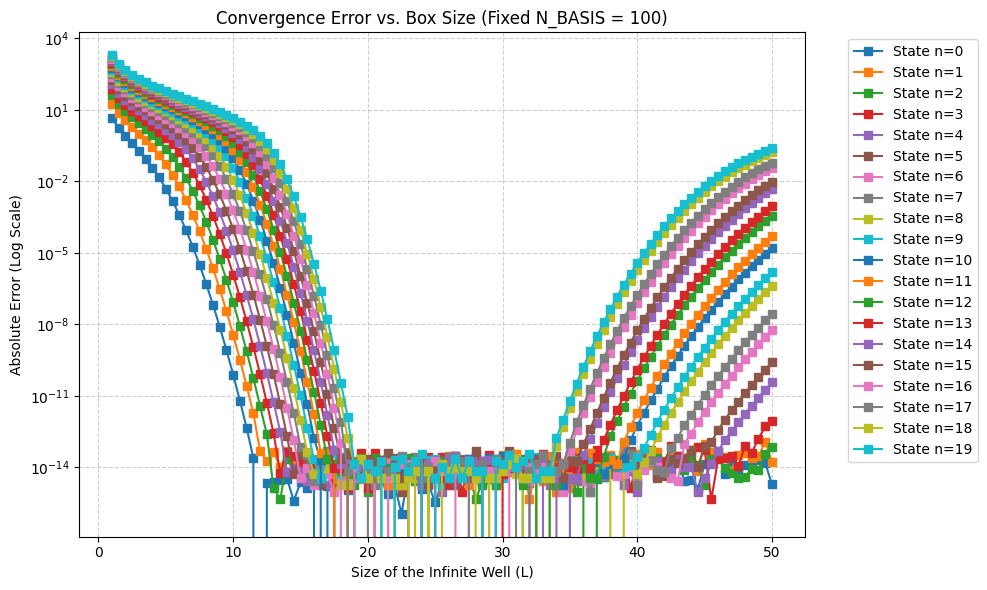

In [24]:
# ==========================================
# Modifying the parameter L: Error vs. Box Size L (Fixed N_BASIS)
# ==========================================

# Experimental Setup
N_fixed = 100  # TODO maybe make this a slider in the notebook for interactivity (or just use the configuration defaults) or maybe find the best one from previous graphs
L_min = 1.0
L_max = 50.0
L_step_size = 0.5
L_values = np.arange(L_min, L_max + L_step_size, L_step_size)
tracked_states = 20

exact_energies = np.array([(cfg.HBAR * cfg.OMEGA) * (n + 0.5) for n in range(tracked_states)])
errors_vs_L = []

print(f"Sweeping L from {L_min} to {L_max} with fixed N_BASIS={N_fixed}...")

for L_val in L_values:
    # Pass the experimental L directly into the math engine
    calc_energies, _ = calculate_qho_energies_and_states(
        L_val=L_val, 
        N_BASIS_val=N_fixed, 
        N_STATES_val=tracked_states
    )
    error = np.abs(calc_energies - exact_energies)
    errors_vs_L.append(error)

errors_vs_L = np.array(errors_vs_L)

# --- Matplotlib Plotting ---
plt.figure(figsize=(10, 6))

# Plotting a subset of the 20 states to keep the graph readable
states_to_plot = [i for i in range(tracked_states)]

for state in states_to_plot:
    plt.semilogy(L_values, errors_vs_L[:, state], marker='s', label=f'State n={state}')

plt.title(f'Convergence Error vs. Box Size (Fixed N_BASIS = {N_fixed})')
plt.xlabel('Size of the Infinite Well (L)')
plt.ylabel('Absolute Error (Log Scale)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

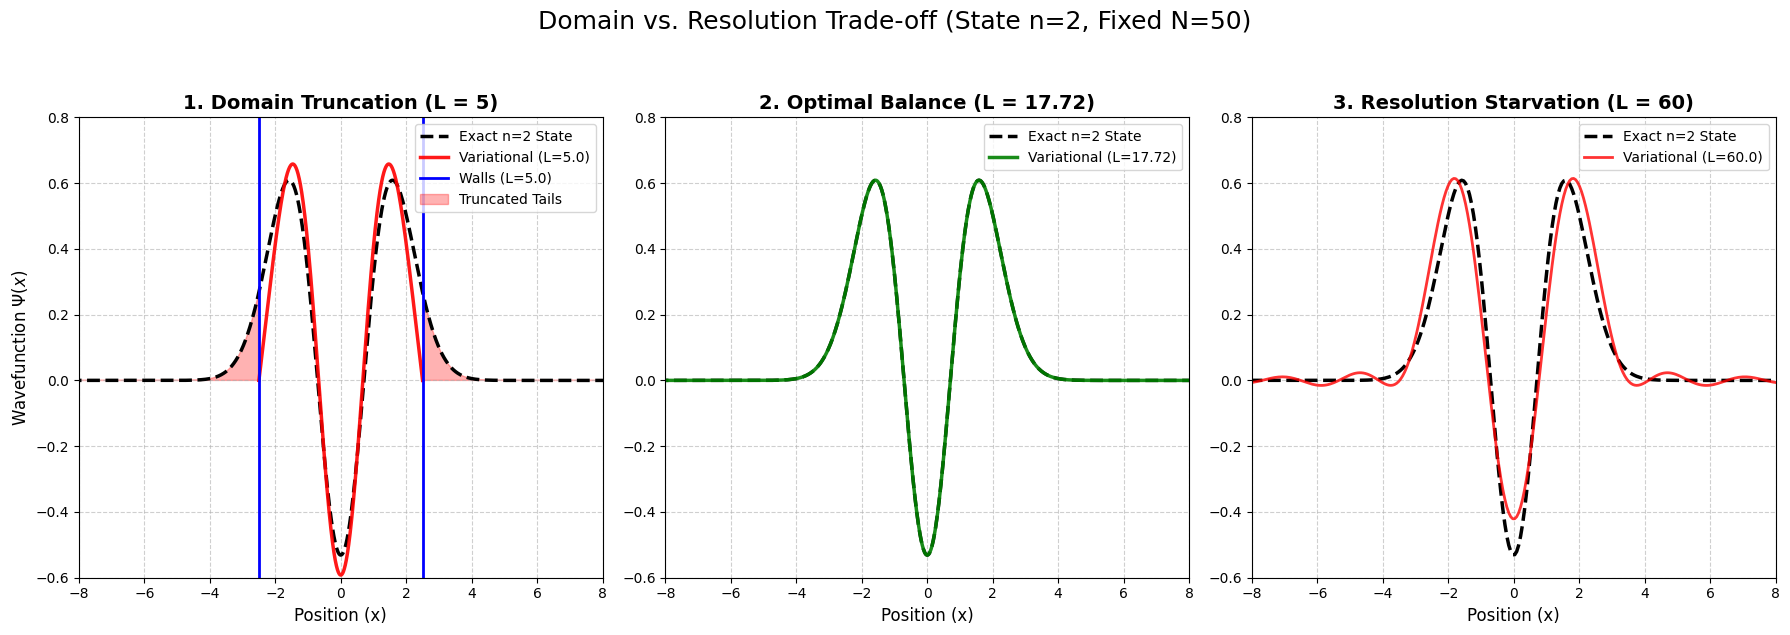

In [25]:
# ==========================================
# The Domain-Resolution Trade-off (State n = 2)
# ==========================================

state = 2  # Using a higher energy state to make truncation obvious!
N_fixed = 50 # Using a lower N to make resolution starvation obvious!
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ---------------------------------------------------------
# 1. Boundary Truncation (L = 5)
# ---------------------------------------------------------
ax1 = axes[0]
L_small = 5.0
x_wide = np.linspace(-10, 10, 1000)
x_small_box = np.linspace(-L_small/2, L_small/2, 1000)

# Exact State
psi_exact_small = exact_qho_wavefunction(x_wide, state)
ax1.plot(x_wide, psi_exact_small, 'k--', linewidth=2.5, label='Exact n=2 State')

# Numerical State (Forced to be zero at the walls)
_, test_states_small = calculate_qho_energies_and_states(L_small, N_fixed, state + 1)
psi_exact_small_box = exact_qho_wavefunction(x_small_box, state)
psi_num_small = reconstruct_numerical_wavefunction(x_small_box, L_small, N_fixed, test_states_small[:, state])

# Phase match
if np.sign(psi_num_small[np.argmax(np.abs(psi_exact_small_box))]) != np.sign(psi_exact_small_box[np.argmax(np.abs(psi_exact_small_box))]):
    psi_num_small *= -1

ax1.plot(x_small_box, psi_num_small, 'r-', alpha=0.9, linewidth=2.5, label=f'Variational (L={L_small})')

# Visuals
ax1.axvline(-L_small/2, color='b', linestyle='-', linewidth=2, label=f'Walls (L={L_small})')
ax1.axvline(L_small/2, color='b', linestyle='-', linewidth=2)
ax1.fill_between(x_wide, psi_exact_small, where=(x_wide < -L_small/2) | (x_wide > L_small/2), color='red', alpha=0.3, label='Truncated Tails')

ax1.set_title('1. Domain Truncation (L = 5)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Position (x)', fontsize=12)
ax1.set_ylabel(r'Wavefunction $\Psi(x)$', fontsize=12)
ax1.set_xlim([-8, 8])
ax1.set_ylim([-0.6, 0.8])
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)

# ---------------------------------------------------------
# 2. The Optimal Zone (Dynamically Calculated)
# ---------------------------------------------------------
ax2 = axes[1]

# Calculate optimal L analytically so the graph automatically adapts to N! (see explanation in markdown cell below)
L_opt = np.sqrt((2 * np.pi * N_fixed * cfg.HBAR) / (cfg.MASS * cfg.OMEGA)) 
x_opt = np.linspace(-L_opt/2, L_opt/2, 1000)

_, test_states_opt = calculate_qho_energies_and_states(L_opt, N_fixed, state + 1)
psi_exact_opt = exact_qho_wavefunction(x_opt, state)
psi_num_opt = reconstruct_numerical_wavefunction(x_opt, L_opt, N_fixed, test_states_opt[:, state])

if np.sign(psi_num_opt[np.argmax(np.abs(psi_exact_opt))]) != np.sign(psi_exact_opt[np.argmax(np.abs(psi_exact_opt))]):
    psi_num_opt *= -1

ax2.plot(x_opt, psi_exact_opt, 'k--', linewidth=2.5, label='Exact n=2 State')
ax2.plot(x_opt, psi_num_opt, 'g-', alpha=0.9, linewidth=2.5, label=f'Variational (L={L_opt:.2f})')

ax2.set_title(f'2. Optimal Balance (L = {L_opt:.2f})', fontsize=14, fontweight='bold')
ax2.set_xlabel('Position (x)', fontsize=12)
ax2.set_xlim([-8, 8]) 
ax2.set_ylim([-0.6, 0.8])
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

# ---------------------------------------------------------
# 3. Resolution Starvation (L = 60)
# ---------------------------------------------------------
ax3 = axes[2]
L_large = 60.0   
x_large = np.linspace(-L_large/2, L_large/2, 1000)

_, test_states_large = calculate_qho_energies_and_states(L_large, N_fixed, state + 1)
psi_exact_large = exact_qho_wavefunction(x_large, state)
psi_num_large = reconstruct_numerical_wavefunction(x_large, L_large, N_fixed, test_states_large[:, state])

if np.sign(psi_num_large[np.argmax(np.abs(psi_exact_large))]) != np.sign(psi_exact_large[np.argmax(np.abs(psi_exact_large))]):
    psi_num_large *= -1

ax3.plot(x_large, psi_exact_large, 'k--', linewidth=2.5, label='Exact n=2 State')
ax3.plot(x_large, psi_num_large, 'r-', alpha=0.8, linewidth=2, label=f'Variational (L={L_large})')

ax3.set_title('3. Resolution Starvation (L = 60)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Position (x)', fontsize=12)
ax3.set_xlim([-8, 8]) 
ax3.set_ylim([-0.6, 0.8])
ax3.legend(loc='upper right')
ax3.grid(True, linestyle='--', alpha=0.6)

plt.suptitle(f'Domain vs. Resolution Trade-off (State n=2, Fixed N={N_fixed})', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

In [26]:
def calculate_wavefunction_errors(psi_exact, psi_num, x_grid):
    """Calculates multiple error metrics for a numerical wavefunction."""
    dx = x_grid[1] - x_grid[0]
    
    # 1. L2 Norm of the difference
    diff_vector = psi_exact - psi_num
    l2_error = np.sqrt(np.sum(np.abs(diff_vector)**2) * dx)
    
    # 2. Maximum Absolute Error (L-infinity)
    max_error = np.max(np.abs(diff_vector))
    
    return l2_error, max_error

Calculating Wavefunction Errors for State n=0 across 550 domain sizes...


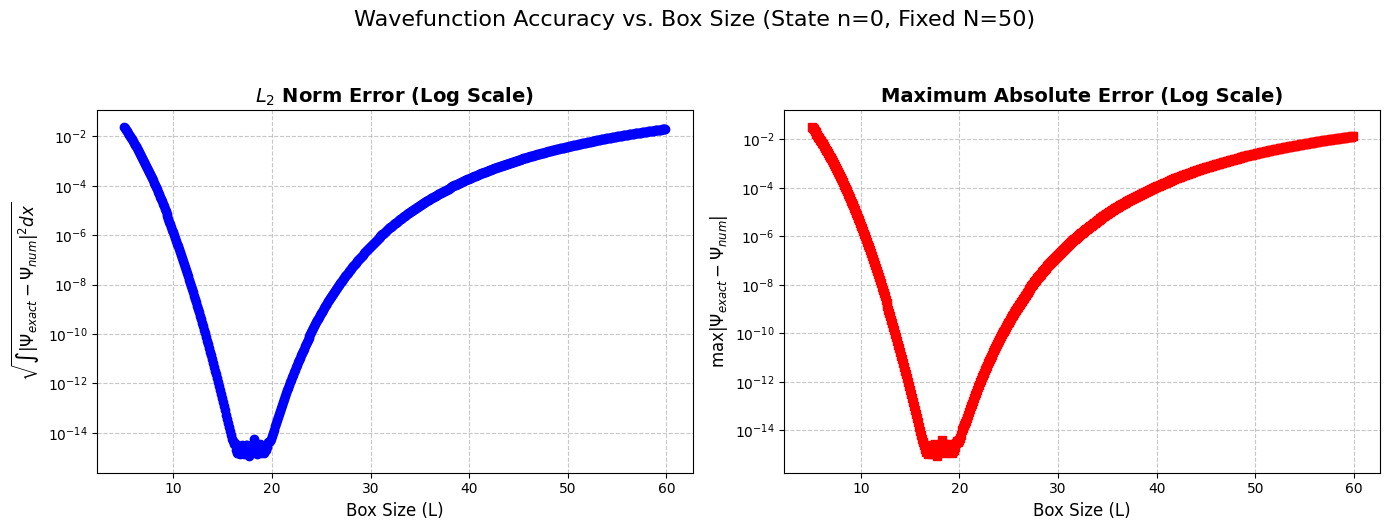


--- Results Summary ---
Optimal Box Size (L)   : 17.7
Minimum L2 Error       : 1.13e-15


In [27]:
# ==========================================
# Wavefunction Error Metrics vs. Domain Size (L)
# ==========================================

N_fixed = 50
state = 0  # Tracking the ground state
L_values = np.arange(5, 60, 0.1) # Sweep from too small (5) to too large (60)

l2_errors = []
max_errors = []

print(f"Calculating Wavefunction Errors for State n={state} across {len(L_values)} domain sizes...")

for L in L_values:
    # 1. Create the spatial grid for this specific box size
    x_grid = np.linspace(-L/2, L/2, 2000)
    
    # 2. Get Exact Wavefunction
    psi_exact = exact_qho_wavefunction(x_grid, state)
    
    # 3. Get Numerical Wavefunction
    _, test_states = calculate_qho_energies_and_states(L, N_fixed, state + 1)
    psi_num = reconstruct_numerical_wavefunction(x_grid, L, N_fixed, test_states[:, state])
    
    # 4. Phase Matching (CRITICAL: Match the signs at the peak before comparing!)
    peak_idx = np.argmax(np.abs(psi_exact))
    if np.sign(psi_num[peak_idx]) != np.sign(psi_exact[peak_idx]):
        psi_num *= -1
        
    # 5. Calculate Errors using the custom function
    l2, mx = calculate_wavefunction_errors(psi_exact, psi_num, x_grid)
    
    l2_errors.append(l2)
    max_errors.append(mx)

# Convert to arrays for plotting
l2_errors = np.array(l2_errors)
max_errors = np.array(max_errors)

# --- Plotting the Results ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: L2 Norm (Total Integral Error)
axes[0].semilogy(L_values, l2_errors, 'b-o', linewidth=2)
axes[0].set_title(r'$L_2$ Norm Error (Log Scale)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Box Size (L)', fontsize=12)
axes[0].set_ylabel(r'$\sqrt{\int |\Psi_{exact} - \Psi_{num}|^2 dx}$', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Maximum Absolute Error (L-infinity Norm)
axes[1].semilogy(L_values, max_errors, 'r-s', linewidth=2)
axes[1].set_title(r'Maximum Absolute Error (Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Box Size (L)', fontsize=12)
axes[1].set_ylabel(r'$\max |\Psi_{exact} - \Psi_{num}|$', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.suptitle(f'Wavefunction Accuracy vs. Box Size (State n={state}, Fixed N={N_fixed})', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

# Print out the optimal L based on L2 error
optimal_idx = np.argmin(l2_errors)
print(f"\n--- Results Summary ---")
print(f"Optimal Box Size (L)   : {L_values[optimal_idx]:.1f}")
print(f"Minimum L2 Error       : {l2_errors[optimal_idx]:.2e}")

Sweeping Omega over 199 values with fixed L=17.699999999999953...


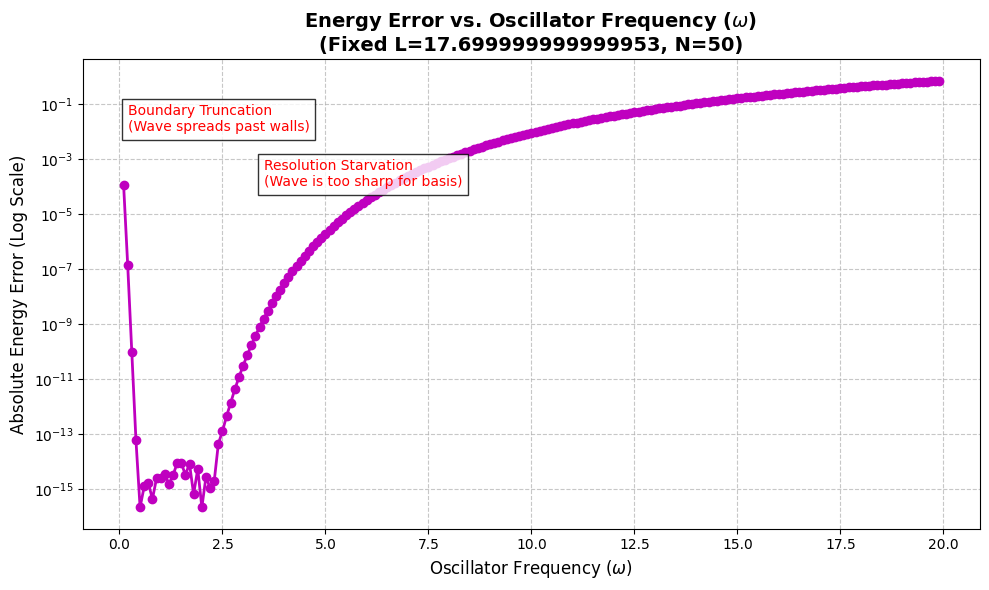

In [28]:
# ==========================================
# Parameter Sweep: Error vs. Oscillator Frequency (Omega)
# ==========================================

N_fixed = 50
L_fixed = L_values[optimal_idx] 
state = 0

omega_values = np.arange(0.1, 20.0, 0.1)
energy_errors = []

print(f"Sweeping Omega over {len(omega_values)} values with fixed L={L_fixed}...")

for w in omega_values:
    # 1. Exact Energy: E_0 = 0.5 * hbar * omega
    exact_E = 0.5 * cfg.HBAR * w
    
    # 2. Numerical Energy (Cleanly passing omega as an argument!)
    calc_energies, _ = calculate_qho_energies_and_states(L_fixed, N_fixed, 1, omega=w)
    
    # 3. Record the Absolute Error
    energy_errors.append(np.abs(exact_E - calc_energies[state]))

energy_errors = np.array(energy_errors)

# --- Plotting the Results ---
plt.figure(figsize=(10, 6))
plt.semilogy(omega_values, energy_errors, 'm-o', linewidth=2)

# Beautify (Notice the double backslashes for \\omega to fix the syntax warning)
plt.title(f'Energy Error vs. Oscillator Frequency ($\\omega$) \n(Fixed L={L_fixed}, N={N_fixed})', fontsize=14, fontweight='bold')
plt.xlabel('Oscillator Frequency ($\\omega$)', fontsize=12)
plt.ylabel('Absolute Energy Error (Log Scale)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Add text annotations to explain the physics
plt.text(0.2, 1e-2, 'Boundary Truncation\n(Wave spreads past walls)', color='red', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.text(3.5, 1e-4, 'Resolution Starvation\n(Wave is too sharp for basis)', color='red', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

## Analytical Derivation of the Optimal Computational Domain ($L_{opt}$)

Our empirical data shows that the optimal domain size $L$ must scale dynamically with both the physical parameters of the oscillator ($\omega$) and the mathematical capacity of our basis set ($N$). We can prove this relationship analytically by balancing the two extremes of our error curve.

### The Energy Balance Equation
The "bottom of the bucket" occurs exactly where the physical potential energy at the artificial boundary equals the maximum kinetic energy capacity of the truncated basis set.

**1. Potential Energy at the Boundary (Domain Truncation Limit)**
The true potential is $V(x) = \frac{1}{2}m\omega^2x^2$. 
Evaluating this at the physical walls of our symmetric box ($x = \pm L/2$), the energy barrier forced upon the system is:
$$V(L/2) = \frac{1}{2}m\omega^2 \left(\frac{L}{2}\right)^2 = \frac{1}{8}m\omega^2L^2$$

**2. Maximum Kinetic Energy of the Basis (Resolution Starvation Limit)**
The highest spatial frequency we can resolve is dictated by our highest basis state, $N$. The kinetic energy of the $N$-th state in an infinite square well is:
$$E_N = \frac{N^2 \pi^2 \hbar^2}{2 m L^2}$$

### Solving for $L_{opt}$
By equating the boundary potential to the maximum basis energy, we find the exact point of numerical harmony:
$$\frac{1}{8}m\omega^2L^2 = \frac{N^2 \pi^2 \hbar^2}{2 m L^2}$$

Multiplying both sides by $L^2$ and isolating $L$:
$$L^4 = \frac{8 N^2 \pi^2 \hbar^2}{2 m^2 \omega^2} = \frac{4 N^2 \pi^2 \hbar^2}{m^2 \omega^2}$$

Taking the fourth root yields the exact analytical formula for the optimal computational domain:
$$L_{opt} = \sqrt{ \frac{2 \pi N \hbar}{m \omega} }$$

In [29]:
print(f"Optimal Box Size (L) (numerical calculation)   : {L_values[optimal_idx]:.1f}")
print(f"Optimal Box Size (L) (analytical calculation)   : {np.sqrt((2 * np.pi * N_fixed * cfg.HBAR )/ (cfg.MASS * cfg.OMEGA))}")


Optimal Box Size (L) (numerical calculation)   : 17.7
Optimal Box Size (L) (analytical calculation)   : 17.72453850905516


In [30]:
# --- Calculating Observables with Optimal L ---
L_opt = L_values[optimal_idx] 
N_fixed = 50
state = 0
x_grid = np.linspace(-L_opt/2, L_opt/2, 2000)
dx = x_grid[1] - x_grid[0]

# 1. Generate the Optimal Wavefunction
_, test_states_opt = calculate_qho_energies_and_states(L_opt, N_fixed, state + 1)
psi_opt = reconstruct_numerical_wavefunction(x_grid, L_opt, N_fixed, test_states_opt[:, state])

# Normalize it just to be absolutely safe
psi_opt = psi_opt / np.sqrt(np.sum(np.abs(psi_opt)**2) * dx)

# 2. Calculate Expectation Value of Potential Energy: <V> = <Psi | 0.5 * m * w^2 * x^2 | Psi>
V_x = 0.5 * cfg.MASS * (cfg.OMEGA * x_grid)**2
expected_V = np.sum(np.conj(psi_opt) * V_x * psi_opt) * dx

# 3. Print the Virial Theorem Proof
exact_total_E = 0.5 * cfg.HBAR * cfg.OMEGA
print(f"--- Physical Observables (Virial Theorem) ---")
print(f"Using dynamically found Optimal L: {L_opt:.1f}")
print(f"Exact Total Energy (E)           : {exact_total_E:.5f}")
print(f"Exact V expected (E / 2)         : {exact_total_E / 2:.5f}")
print(f"Numerical <V> from wave          : {expected_V:.5f}")
print(f"Difference                       : {abs((exact_total_E / 2) - expected_V):.2e}")

--- Physical Observables (Virial Theorem) ---
Using dynamically found Optimal L: 17.7
Exact Total Energy (E)           : 0.50000
Exact V expected (E / 2)         : 0.25000
Numerical <V> from wave          : 0.25000
Difference                       : 1.67e-16
